In [1]:
#import libraries
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import r2_score, mean_squared_error
import mne
import asrpy
import warnings
from sklearn.exceptions import ConvergenceWarning


In [2]:
# Helper Functions
def norm_freq(f, fs): return f * 2 / fs

def filter(data, fs):
    b_notch, a_notch = scipy.signal.iirnotch(50, Q=30, fs=fs)
    wn = (norm_freq(2, fs), norm_freq(60, fs))
    sos_band = scipy.signal.butter(N=4, Wn=wn, btype='bandpass', output='sos')
    filtered = np.zeros_like(data)
    for ch in range(data.shape[1]):
        x = data[:, ch]
        x_notched = scipy.signal.lfilter(b_notch, a_notch, x)
        filtered[:, ch] = scipy.signal.sosfilt(sos_band, x_notched)
    return filtered

def ASR(data, fs):
    data_T = data.T 
    info = mne.create_info(ch_names=[f"ch{i}" for i in range(data_T.shape[0])], sfreq=fs, ch_types="eeg")
    raw_T = mne.io.RawArray(data_T, info, verbose=False)
    asr = asrpy.ASR(sfreq=fs, cutoff=20.0)  
    asr.fit(raw_T)  
    return asr.transform(raw_T).get_data().T

def time_domain_features(data, fs):
    features = np.zeros((data.shape[1], 3))
    for ch in range(data.shape[1]):
        signal = data[:, ch]
        hist, bin_edges = np.histogram(signal, bins=50, density=True)
        p = hist * np.diff(bin_edges)
        p = p[p > 0]
        features[ch, :] = [-np.sum(p * np.log2(p)), np.var(signal, ddof=1), np.sum(np.diff(np.sign(signal)) != 0) / len(signal)]
    return features

def freq_domain_features(data, fs):
    bands = [(0, 4), (4, 8), (8, 12), (12, 40), (40, 100)]
    features = np.zeros((data.shape[1], len(bands) + 3))
    for ch in range(data.shape[1]):
        signal = data[:, ch]
        fft_vals = np.fft.fft(signal)
        freqs = np.fft.fftfreq(len(signal), 1/fs)
        pos_freqs = freqs[:len(signal)//2]
        energies = np.abs(fft_vals[:len(signal)//2])**2
        
        band_energies = [np.sum(energies[(pos_freqs >= b[0]) & (pos_freqs <= b[1])]) for b in bands]
        max_freq = pos_freqs[np.argmax(energies)]
        mean_freq = np.sum(pos_freqs * energies) / np.sum(energies)
        ps_norm = energies / np.sum(energies)
        features[ch, :] = np.concatenate([band_energies, [max_freq, mean_freq, -np.sum(ps_norm * np.log2(ps_norm + 1e-12))]])
    return features

def extract_features_from_window(window, fs):
    time_feat = time_domain_features(window, fs)
    freq_feat = freq_domain_features(window, fs)
    return np.concatenate([time_feat.flatten(), freq_feat.flatten()])

def build_dataset(all_data, fs, window_size, step_size):
    X, y = [], []
    print(f"Building dataset from {len(all_data)} files...")
    for d in all_data:
        data_trig = d[:, -1]
        data = ASR(filter(d[:, 0:8], fs), fs)
        start = 0
        while start + window_size <= data.shape[0]:
            window = data[start:start + window_size, :]
            X.append(extract_features_from_window(window, fs))
            y.append(data_trig[start:start + window_size][window_size//2])
            start += step_size
    return np.array(X), np.array(y)

def train_model(X, y, max_iter=300):

    #supress max_iter=1 convergence warnings
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    
    print("Training MLPClassifier...")
    mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", solver="adam", max_iter=1, warm_start=True)
    
    losses, accuracies = [], []
    for i in range(max_iter):
        mlp.fit(X_train, y_train)
        losses.append(mlp.loss_)
        accuracies.append(mlp.score(X_train, y_train))
        
    print(f"Training accuracy: {mlp.score(X_train, y_train):.2f}")
    print(f"Test accuracy: {mlp.score(X_test, y_test):.2f}")
    
    fig, ax1 = plt.subplots(figsize=(8,5))
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Loss', color='tab:blue')
    ax1.plot(range(1, max_iter+1), losses, color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True)
    
    ax2 = ax1.twinx()
    ax2.set_ylabel('Training Accuracy', color='tab:red')
    ax2.plot(range(1, max_iter+1), accuracies, color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    plt.title('MLP Training Loss and Accuracy over Iterations')
    plt.show()
    
    return mlp, scaler

def analyze_focus(filename, mlp_model, scaler, fs=500, step_sec=0.05, smooth_sec=5):
    print(f"--- Analyzing: {filename} ---")
    try:
        raw = np.genfromtxt(filename, delimiter=',')[1:, 0:8]
    except: 
        return print("Error loading file.")
        
    data = ASR(filter(raw, fs), fs)
    win_size, step = int(1*fs), int(step_sec*fs)
    if step < 1: step = 1
    
    feats, times = [], []
    for i in range((data.shape[0] - win_size) // step):
        s = i * step
        feats.append(extract_features_from_window(data[s:s+win_size], fs))
        times.append((s+win_size)/fs)
        if i % 200 == 0: print(".", end="", flush=True)
    print(" Done.")
    
    if len(feats) == 0: return
    
    X_scaled = scaler.transform(np.array(feats))
    raw_scores = mlp_model.predict_proba(X_scaled)[:, 1] * 100
    
    k_size = max(1, int(smooth_sec / step_sec))
    smoothed = np.convolve(raw_scores, np.ones(k_size)/k_size, mode='same')
    smoothed[:k_size//2] = np.nan; smoothed[-k_size//2:] = np.nan
    
    plt.figure(figsize=(12, 6))
    plt.plot(times, raw_scores, color='lightgray', alpha=0.5, label=f'Raw ({step_sec}s step)')
    plt.plot(times, smoothed, color='darkblue', linewidth=2.5, label=f'Trend ({smooth_sec}s average)')
    plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='Threshold (50%)')
    plt.fill_between(times, 0, smoothed, color='blue', alpha=0.1, where=~np.isnan(smoothed))
    plt.ylim(-5, 105)
    plt.xlabel("Time [s]")
    plt.ylabel("Focus Level [%]")
    plt.title(f"Focus Trend: {filename}")
    plt.legend(loc='lower right', framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Building dataset from 9 files...
Training MLPClassifier...
Training accuracy: 1.00
Test accuracy: 0.99


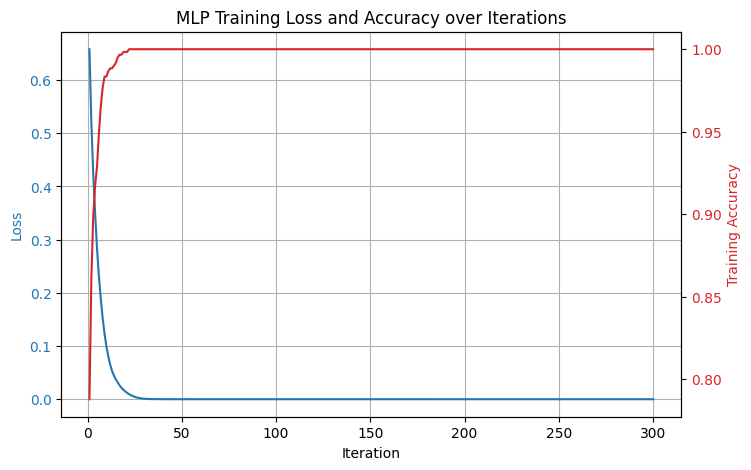

Model Trained Successfully!


In [3]:
# --- Data Loading & Training ---
try:
    # Load Training Data
    f1 = np.genfromtxt('eeg_data/focus1.csv', delimiter=',')[1:]; f1[:,-1]=1
    f2 = np.genfromtxt('eeg_data/focus2.csv', delimiter=',')[1:]; f2[:,-1]=1
    f3 = np.genfromtxt('eeg_data/focus3.csv', delimiter=',')[1:]; f3[:,-1]=1
    f4 = np.genfromtxt('eeg_data/focus4.csv', delimiter=',')[1:]; f4[:,-1]=1
    f5 = np.genfromtxt('eeg_data/focus5.csv', delimiter=',')[1:]; f5[:,-1]=1
    
    r1 = np.genfromtxt('eeg_data/relax1.csv', delimiter=',')[1:]; r1[:,-1]=0
    r2 = np.genfromtxt('eeg_data/relax2.csv', delimiter=',')[1:]; r2[:,-1]=0
    r3 = np.genfromtxt('eeg_data/relax3.csv', delimiter=',')[1:]; r3[:,-1]=0
    r4 = np.genfromtxt('eeg_data/relax4.csv', delimiter=',')[1:]; r4[:,-1]=0
    r5 = np.genfromtxt('eeg_data/relax5.csv', delimiter=',')[1:]; r5[:,-1]=0
    
    all_data = [ f2, f3, f4, f5, r1, r2, r3, r4, r5]
    
    # Build & Train
    fs = 500
    X_train, y_train = build_dataset(all_data, fs, int(1*fs), int(0.9*fs))
    mlp_model, scaler = train_model(X_train, y_train)
    print("Model Trained Successfully!")
    
except Exception as e:
    print(f"Training failed: {e}")

--- Analyzing: eeg_data/chess.csv ---
........ Done.


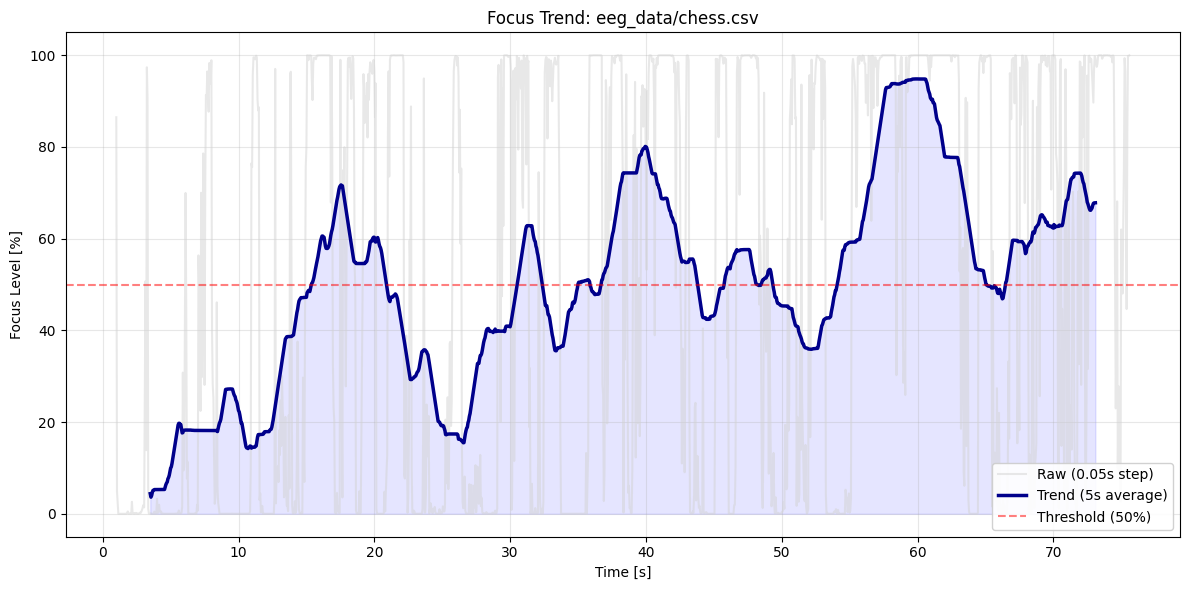

--- Analyzing: eeg_data/tetris1.csv ---
.................... Done.


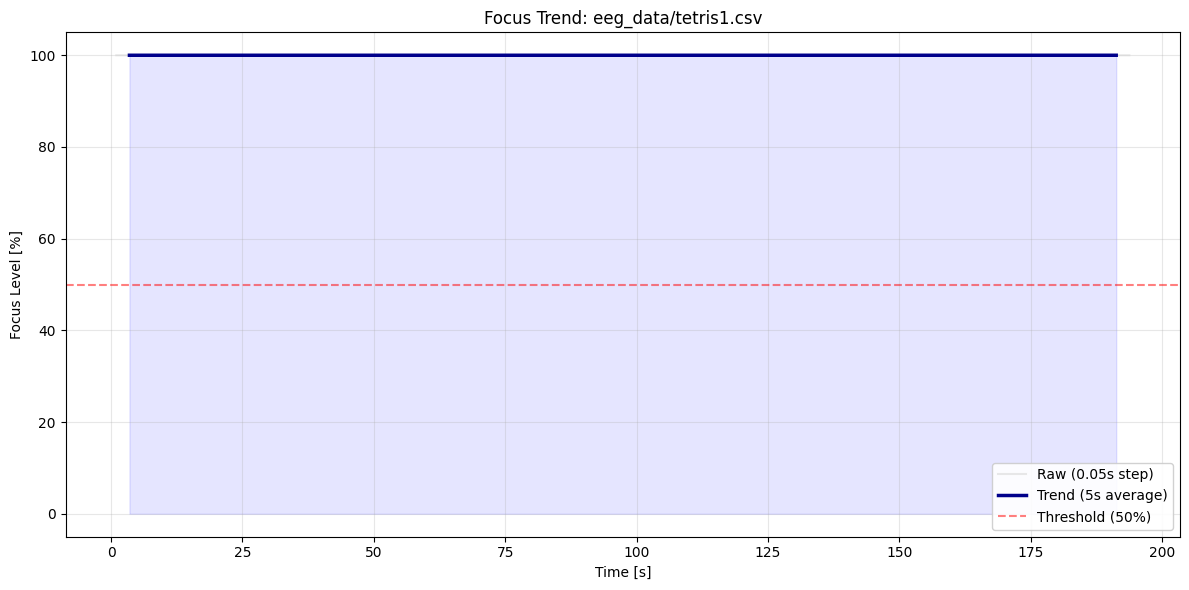

--- Analyzing: eeg_data/tetris2.csv ---
..................................... Done.


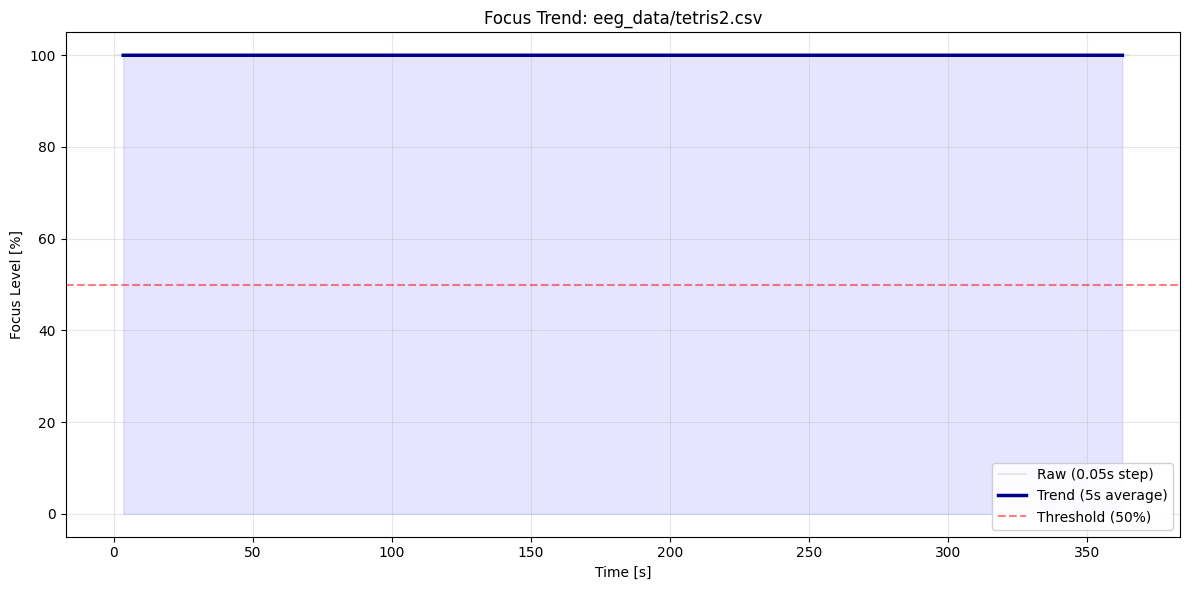

In [ ]:
# Plot mental effort during games (Chess and Tetris)
game_files = [
    'eeg_data/chess.csv',
    'eeg_data/tetris1.csv',
]

for game in game_files:
    analyze_focus(
        filename=game, 
        mlp_model=mlp_model, 
        scaler=scaler, 
        fs=500, 
        step_sec=0.05, 
        smooth_sec=5
    )